# Project Overview & Dataset

## Problem Statement
The objective of this project is to develop a machine learning model capable of automatically categorizing IT support tickets.

## Dataset Description
This project uses the IT Support Ticket Data dataset.

# Project Setup

In [1]:
import kagglehub
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import re

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


# stopwords removal imports
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

/home/jano/src/python/IT-ticket-classifier/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Download dataset

In [2]:
# Download latest version

DATA_FOLDER = "../data"

FILE_NAME = "IT Support Ticket Data.csv"

path = kagglehub.dataset_download("parthpatil256/it-support-ticket-data")

print("Dataset downloaded to cache:", path)

if not os.path.exists(DATA_FOLDER):
    os.mkdir(DATA_FOLDER)
    print(f"Folder created: {DATA_FOLDER}")

src_path = os.path.join(path, FILE_NAME)
dest_path = os.path.join(DATA_FOLDER, FILE_NAME)

if not os.path.exists(dest_path):
    if os.path.exists(src_path):
        print(f"Copying '{FILE_NAME}' to the project folder...")
        shutil.copy(src_path, dest_path)
        print("Copy finished successfully.")
    else:
        print(f"File '{FILE_NAME}' not found in the downloaded files.")
else:
    print(f"File '{FILE_NAME}' already exists in {DATA_FOLDER}. Skipping copy.")

# Verification
print(f"Files in {DATA_FOLDER}: {os.listdir(DATA_FOLDER)}")

Dataset downloaded to cache: /home/jano/.cache/kagglehub/datasets/parthpatil256/it-support-ticket-data/versions/1
File 'IT Support Ticket Data.csv' already exists in ../data. Skipping copy.
Files in ../data: ['IT Support Ticket Data.csv']


# Load and Exploratory Data Analysis

## Basic Dataset Inspection

In [3]:
df_original = pd.read_csv(dest_path, index_col=0)

# basic info
print("Dataset info:")
print(df_original.info())
print("#"*50)
print("\nFirst 5 rows:")
display(df_original.head(5))
print("\nDataset shape:")
print(df_original.shape)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 29651 entries, 0 to 29650
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Body        29650 non-null  str  
 1   Department  29651 non-null  str  
 2   Priority    29651 non-null  str  
 3   Tags        29651 non-null  str  
dtypes: str(4)
memory usage: 926.7 KB
None
##################################################

First 5 rows:


,Body,Department,Priority,Tags
0,"Dear Customer Support Team,I am writing to rep...",Technical Support,high,"['Account', 'Disruption', 'Outage', 'IT', 'Tec..."
1,"Dear Customer Support Team,I hope this message...",Returns and Exchanges,medium,"['Product', 'Feature', 'Tech Support']"
2,"Dear Customer Support Team,I hope this message...",Billing and Payments,low,"['Billing', 'Payment', 'Account', 'Documentati..."
3,"Dear Support Team,I hope this message reaches ...",Sales and Pre-Sales,medium,"['Product', 'Feature', 'Feedback', 'Tech Suppo..."
4,"Dear Customer Support,I hope this message reac...",Technical Support,high,"['Feature', 'Product', 'Documentation', 'Feedb..."



Dataset shape:
(29651, 4)


## Distribution of Objective Variables

In [4]:
print("--- Department distribution in percentage ---")
display((df_original["Department"].value_counts(normalize=True)*100).round(2))

print("\n--- Priority distribution in percentage ---")
display((df_original["Priority"].value_counts(normalize=True)*100).round(2))

--- Department distribution in percentage ---


Department
Technical Support                  29.06
Product Support                    18.68
Customer Service                   15.12
IT Support                         11.80
Billing and Payments               10.18
Returns and Exchanges               4.95
Service Outages and Maintenance     3.90
Sales and Pre-Sales                 2.98
Human Resources                     1.92
General Inquiry                     1.41
Name: proportion, dtype: float64


--- Priority distribution in percentage ---


Priority
medium    40.90
high      38.82
low       20.28
Name: proportion, dtype: float64

## Missing Data Detection

Text representation:

Department    0
Priority      0
Tags          0
Body          1
dtype: int64

Graphic representation


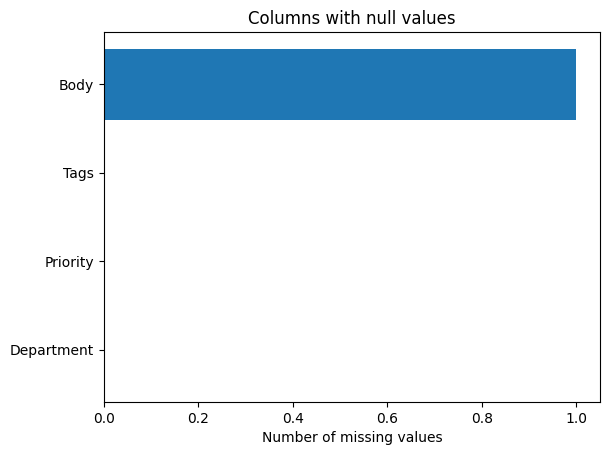

In [5]:
null_sum = df_original.isnull().sum()
null_sum = null_sum.sort_values(ascending=True)
print("Text representation:\n")
print(null_sum)

print("\nGraphic representation")
plt.barh(null_sum.index,null_sum.values)
plt.title("Columns with null values")
plt.xlabel('Number of missing values')
plt.show()

## Objective Variable Distribution

### Department Distribution

Text representation:

Department
Technical Support                  8617
Product Support                    5539
Customer Service                   4482
IT Support                         3500
Billing and Payments               3017
Returns and Exchanges              1467
Service Outages and Maintenance    1157
Sales and Pre-Sales                 885
Human Resources                     568
General Inquiry                     419
Name: count, dtype: int64

Graphic representation


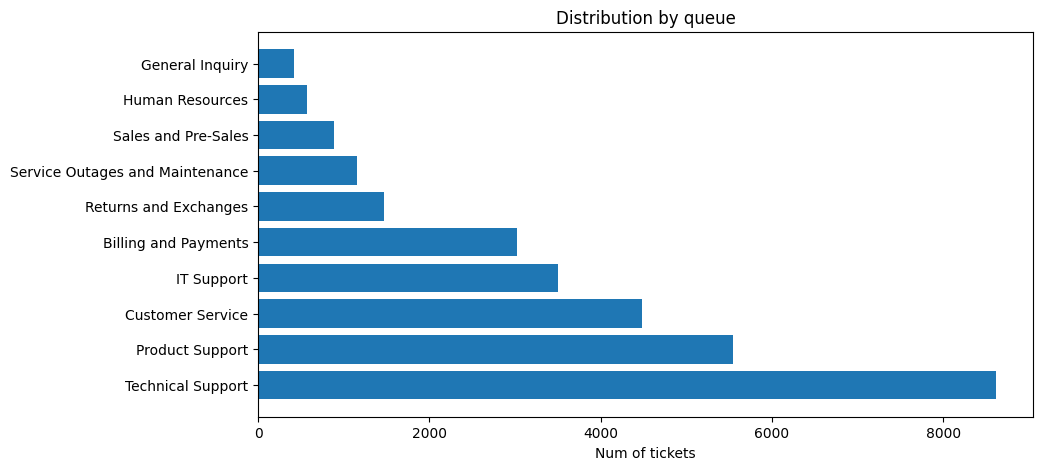

In [6]:
department_tickets = df_original["Department"].value_counts()
print("Text representation:\n")
print(department_tickets)

print("\nGraphic representation")
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(department_tickets.index,department_tickets.values)
ax.set_title("Distribution by queue")
ax.set_xlabel("Num of tickets")
plt.show()

### Priority Distribution

Text representation:

Priority
medium    12126
high      11512
low        6013
Name: count, dtype: int64

Graphic representation


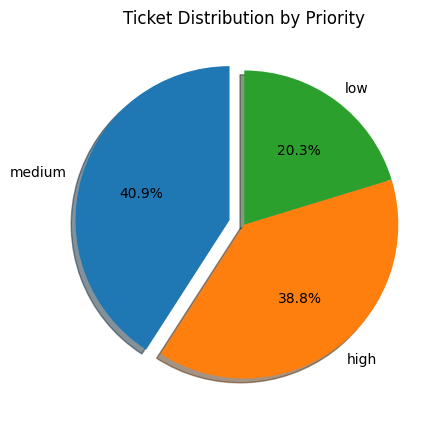

In [7]:
priority_tickets = df_original["Priority"].value_counts()
print("Text representation:\n")
print(priority_tickets)

print("\nGraphic representation")
fig, ax = plt.subplots(figsize=(10, 5))
explode = (0.1, 0, 0)
ax.pie(priority_tickets.values, labels=priority_tickets.index, explode=explode,
        shadow=True, autopct='%1.1f%%', startangle=90)

plt.title("Ticket Distribution by Priority")
plt.show()

## Text Length

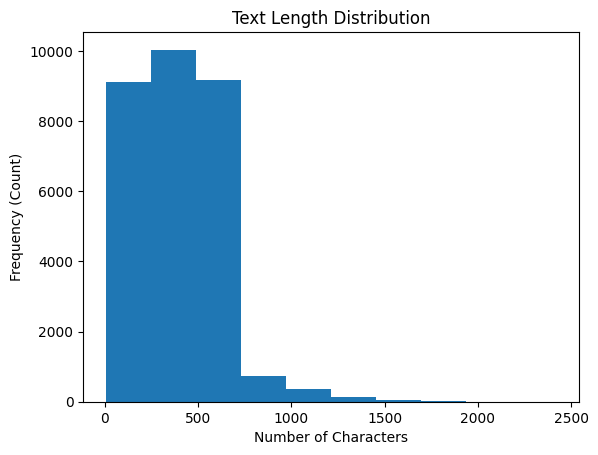

In [8]:
fig, ax = plt.subplots()
ax.hist(df_original["Body"].str.len())
ax.set_title("Text Length Distribution")
ax.set_xlabel("Number of Characters")
ax.set_ylabel("Frequency (Count)")
plt.show()

# Data Preprocessing

In [9]:
# create a copy from the original df to mantain the original dataset untouch
df = df_original.copy()

display(df.info())

display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 29651 entries, 0 to 29650
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Body        29650 non-null  str  
 1   Department  29651 non-null  str  
 2   Priority    29651 non-null  str  
 3   Tags        29651 non-null  str  
dtypes: str(4)
memory usage: 926.7 KB


None

,Body,Department,Priority,Tags
0,"Dear Customer Support Team,I am writing to rep...",Technical Support,high,"['Account', 'Disruption', 'Outage', 'IT', 'Tec..."
1,"Dear Customer Support Team,I hope this message...",Returns and Exchanges,medium,"['Product', 'Feature', 'Tech Support']"
2,"Dear Customer Support Team,I hope this message...",Billing and Payments,low,"['Billing', 'Payment', 'Account', 'Documentati..."
3,"Dear Support Team,I hope this message reaches ...",Sales and Pre-Sales,medium,"['Product', 'Feature', 'Feedback', 'Tech Suppo..."
4,"Dear Customer Support,I hope this message reac...",Technical Support,high,"['Feature', 'Product', 'Documentation', 'Feedb..."


## Drop Null Values

In [10]:
# Drop null values from body
df = df.dropna(subset=["Body"])
df = df.reset_index(drop=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29650 entries, 0 to 29649
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Body        29650 non-null  str  
 1   Department  29650 non-null  str  
 2   Priority    29650 non-null  str  
 3   Tags        29650 non-null  str  
dtypes: str(4)
memory usage: 926.7 KB


## Clean Text

In [25]:
# download stopwords
nltk.download('stopwords')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /home/jano/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/jano/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [20]:
# Select a random ticket to see if it has strange characters
rng = np.random.default_rng()

rand_num = rng.integers(0, len(df))

df["Body"].iloc[rand_num]

"Dear Customer Support, We are contacting you to request assistance in integrating Node.js with Azure for optimizing our data analytics processes. Our team is investigating methods to improve our data analysis capabilities and believe Azure's services can offer the necessary tools to enhance our workflow efficiency. However, we are uncertain about the optimal method to integrate Node.js with Azure. Could you provide us with guidance on this? We would greatly appreciate any recommendations or materials you could share with us. Specifically, we are interested in learning how to establish a Node.js environment on Azure, how to connect to Azure's data services, and how to optimize our data analytics workflows. We are also keen to learn about any best practices or common mistakes to avoid during the integration process. Thank you for your time and help. We look forward to your response. Best regards, [Your Name]"

In [26]:
# Clean literal escape sequences (e.g., \n, \r) and remove extra whitespaces
def clean_text(text):
    text = text.lower()

    # remove sequence escape literals (e.g: \n, \r, \t,...)
    text = re.sub(r'\\[nrt]', ' ', text)

    # remove html tags (e.g: <br>,...)
    text = re.sub(r'<[^>]+>', ' ', text)

    # remove multiple spaces
    text = re.sub(r'\s+', ' ', text)

    # stopword removal
    tokens = word_tokenize(text)

    text = " ".join([word for word in tokens if word not in stop_words])

    return text

df["clean_body"] = df["Body"].apply(clean_text)

df["clean_body"].iloc[rand_num]

"dear customer support , contacting request assistance integrating node.js azure optimizing data analytics processes . team investigating methods improve data analysis capabilities believe azure 's services offer necessary tools enhance workflow efficiency . however , uncertain optimal method integrate node.js azure . could provide us guidance ? would greatly appreciate recommendations materials could share us . specifically , interested learning establish node.js environment azure , connect azure 's data services , optimize data analytics workflows . also keen learn best practices common mistakes avoid integration process . thank time help . look forward response . best regards , [ name ]"

## Target Variable Encoding

In [27]:
# Target Variable Encoding
le = LabelEncoder()

df["encoded_department"] = le.fit_transform(df["Department"])

print(le.classes_)

['Billing and Payments' 'Customer Service' 'General Inquiry'
 'Human Resources' 'IT Support' 'Product Support' 'Returns and Exchanges'
 'Sales and Pre-Sales' 'Service Outages and Maintenance'
 'Technical Support']


## Split Dataset

In [28]:
# split dataset on train and test
X = df['clean_body']

y = df['encoded_department']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print('-> Train shape:')
print(X_train.shape)
print(y_train.shape)

print('\n-> Test shape:')
print(X_test.shape)
print(y_test.shape)

-> Train shape:
(23720,)
(23720,)

-> Test shape:
(5930,)
(5930,)


# Model Training & Evaluation

## Baseline Model

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

base_model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")

base_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

### Evaluate Base model

                                 precision    recall  f1-score   support

           Billing and Payments       0.77      0.75      0.76       604
               Customer Service       0.41      0.34      0.37       896
                General Inquiry       0.17      0.61      0.26        84
                Human Resources       0.27      0.64      0.38       114
                     IT Support       0.35      0.41      0.38       700
                Product Support       0.48      0.33      0.39      1108
          Returns and Exchanges       0.30      0.50      0.37       293
            Sales and Pre-Sales       0.24      0.67      0.36       177
Service Outages and Maintenance       0.41      0.69      0.52       231
              Technical Support       0.58      0.36      0.44      1723

                       accuracy                           0.43      5930
                      macro avg       0.40      0.53      0.42      5930
                   weighted avg       0.48      0

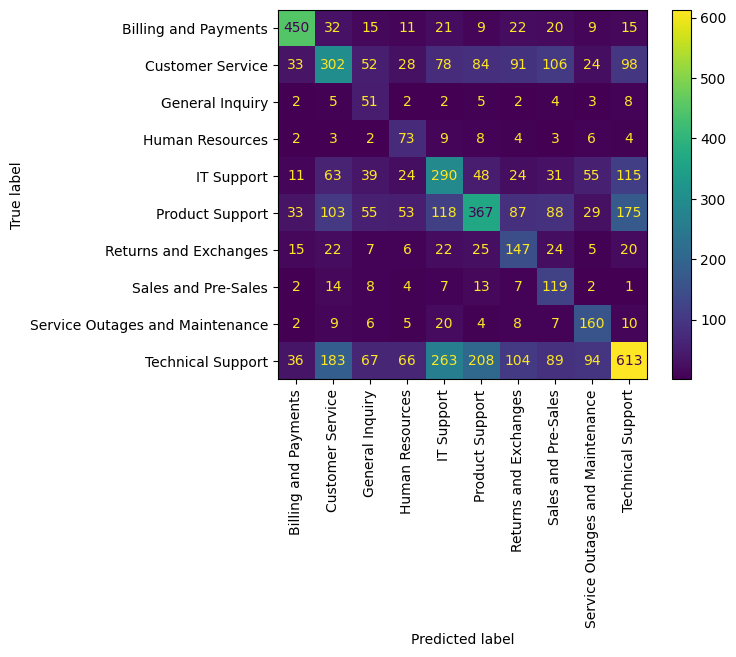

In [44]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = base_model.predict(X_test_tfidf)

print(classification_report(y_test,y_pred, target_names=le.classes_))

disp = ConfusionMatrixDisplay.from_predictions(y_test,y_pred,display_labels=le.classes_, xticks_rotation='vertical')
plt.show()